In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load the dataset
df=pd.read_csv(r"C:\Users\NB00569\Projects\energy-demand-forecasting\data\raw\PJME_hourly.csv")

print("Shape",df.shape)
print("\nFirst 5 rows:")
df.head()

Shape (145366, 2)

First 5 rows:


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [4]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Data Types:
Datetime        str
PJME_MW     float64
dtype: object

Missing Values:
Datetime    0
PJME_MW     0
dtype: int64

Basic Statistics:


,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [5]:
# Convert Datetime column from string to actual datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set it as the index
df = df.set_index('Datetime')

# Sort chronologically
df = df.sort_index()

# Verify
print("Date Range:")
print(f"Start : {df.index.min()}")
print(f"End   : {df.index.max()}")
print(f"\nTotal Records : {len(df):,}")
print(f"\nNew dtypes:")
print(df.dtypes)

Date Range:
Start : 2002-01-01 01:00:00
End   : 2018-08-03 00:00:00

Total Records : 145,366

New dtypes:
PJME_MW    float64
dtype: object


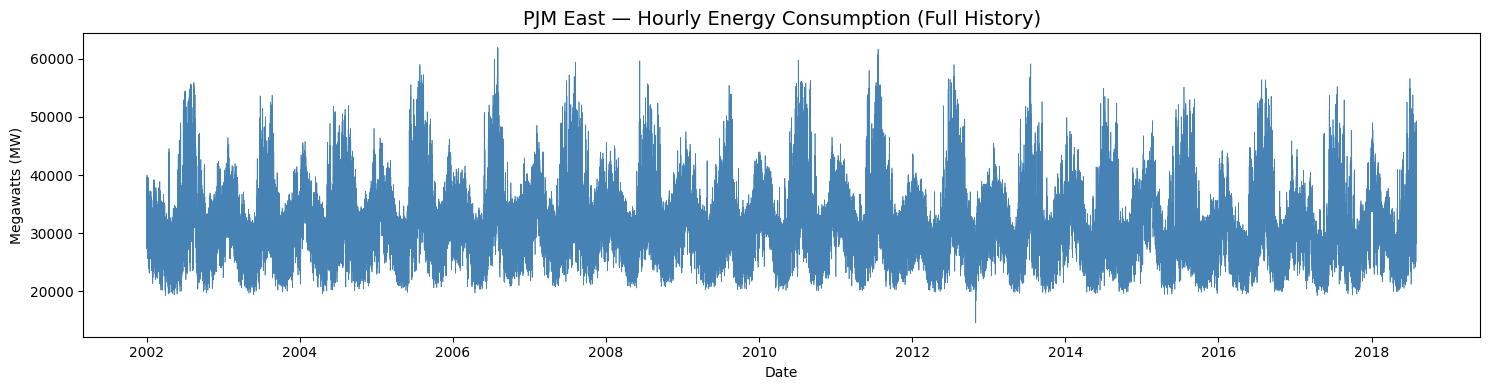

Plot saved to results/plots/


In [6]:
plt.figure(figsize=(15, 4))
plt.plot(df['PJME_MW'], linewidth=0.5, color='steelblue')
plt.title('PJM East — Hourly Energy Consumption (Full History)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Megawatts (MW)')
plt.tight_layout()
plt.savefig('../results/plots/01_raw_data_overview.png', dpi=150)
plt.show()

print("Plot saved to results/plots/")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 12

# Reload data cleanly
df = pd.read_csv(r"C:\Users\NB00569\Projects\energy-demand-forecasting\data\raw\PJME_hourly.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime').sort_index()
df.columns = ['energy_mw']

print("✅ Data loaded successfully")
print(f"Shape      : {df.shape}")
print(f"Start date : {df.index.min()}")
print(f"End date   : {df.index.max()}")
print(f"Total hours: {len(df):,}")

✅ Data loaded successfully
Shape      : (145366, 1)
Start date : 2002-01-01 01:00:00
End date   : 2018-08-03 00:00:00
Total hours: 145,366


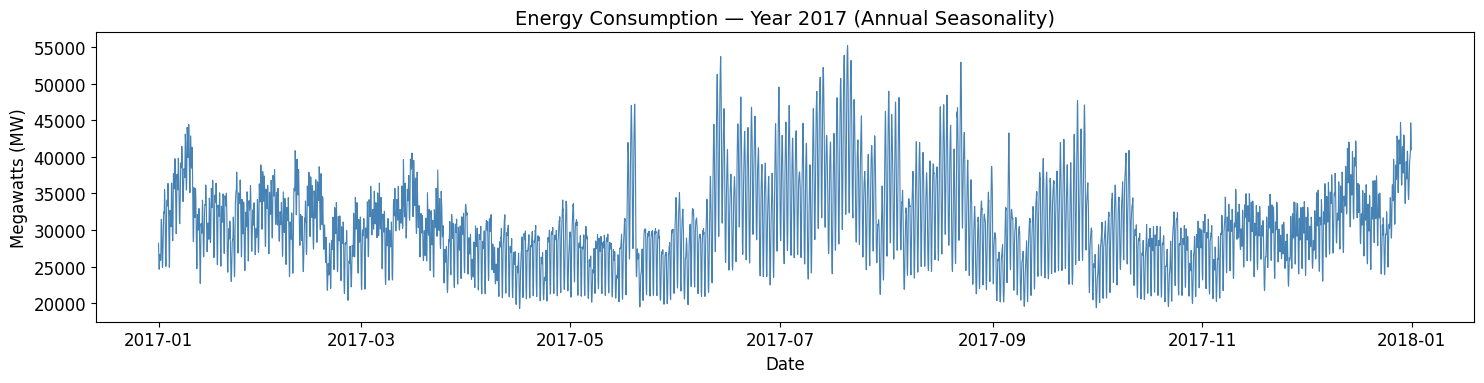

2017 Stats:
Min  : 19,255 MW
Max  : 55,218 MW
Mean : 30,651 MW


In [3]:
# Zoom into one full year to see annual seasonality
year_2017 = df.loc['2017-01-01':'2017-12-31']

plt.figure(figsize=(15, 4))
plt.plot(year_2017['energy_mw'], linewidth=0.8, color='steelblue')
plt.title('Energy Consumption — Year 2017 (Annual Seasonality)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Megawatts (MW)')
plt.tight_layout()
plt.savefig('../results/plots/02_annual_seasonality.png', dpi=150)
plt.show()

print(f"2017 Stats:")
print(f"Min  : {year_2017['energy_mw'].min():,.0f} MW")
print(f"Max  : {year_2017['energy_mw'].max():,.0f} MW")
print(f"Mean : {year_2017['energy_mw'].mean():,.0f} MW")

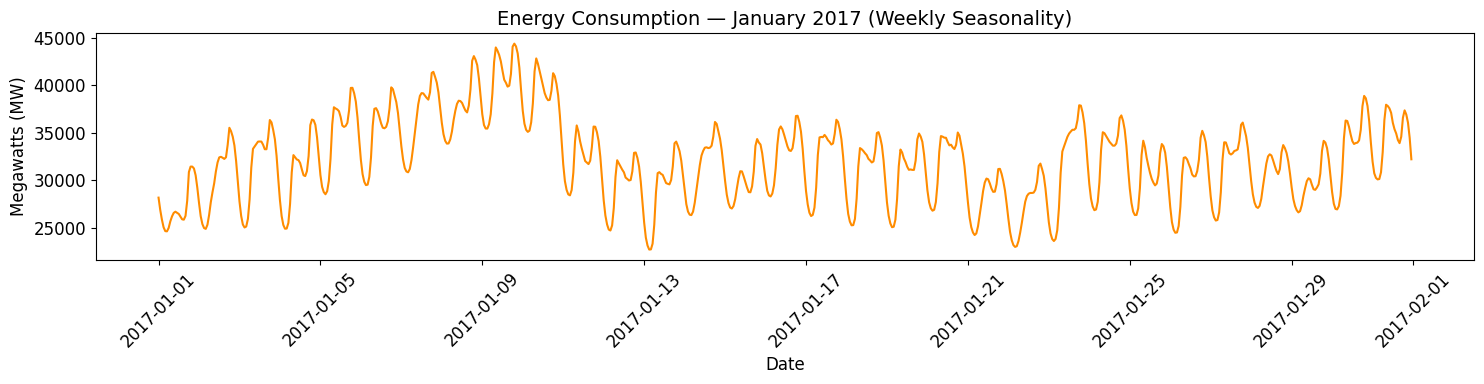

In [4]:
# Zoom into one month to see weekly seasonality
month_jan = df.loc['2017-01-01':'2017-01-31']

plt.figure(figsize=(15, 4))
plt.plot(month_jan['energy_mw'], linewidth=1.5, color='darkorange')
plt.title('Energy Consumption — January 2017 (Weekly Seasonality)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Megawatts (MW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/plots/03_weekly_seasonality.png', dpi=150)
plt.show()

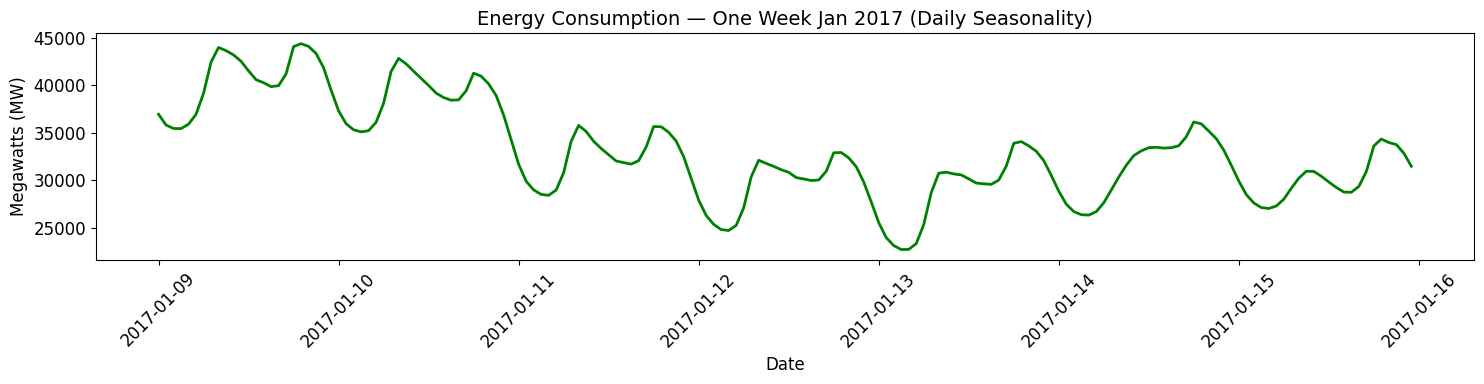

In [5]:
# Zoom into one week to see daily/hourly seasonality
week_jan = df.loc['2017-01-09':'2017-01-15']

plt.figure(figsize=(15, 4))
plt.plot(week_jan['energy_mw'], linewidth=2, color='green')
plt.title('Energy Consumption — One Week Jan 2017 (Daily Seasonality)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Megawatts (MW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/plots/04_daily_seasonality.png', dpi=150)
plt.show()

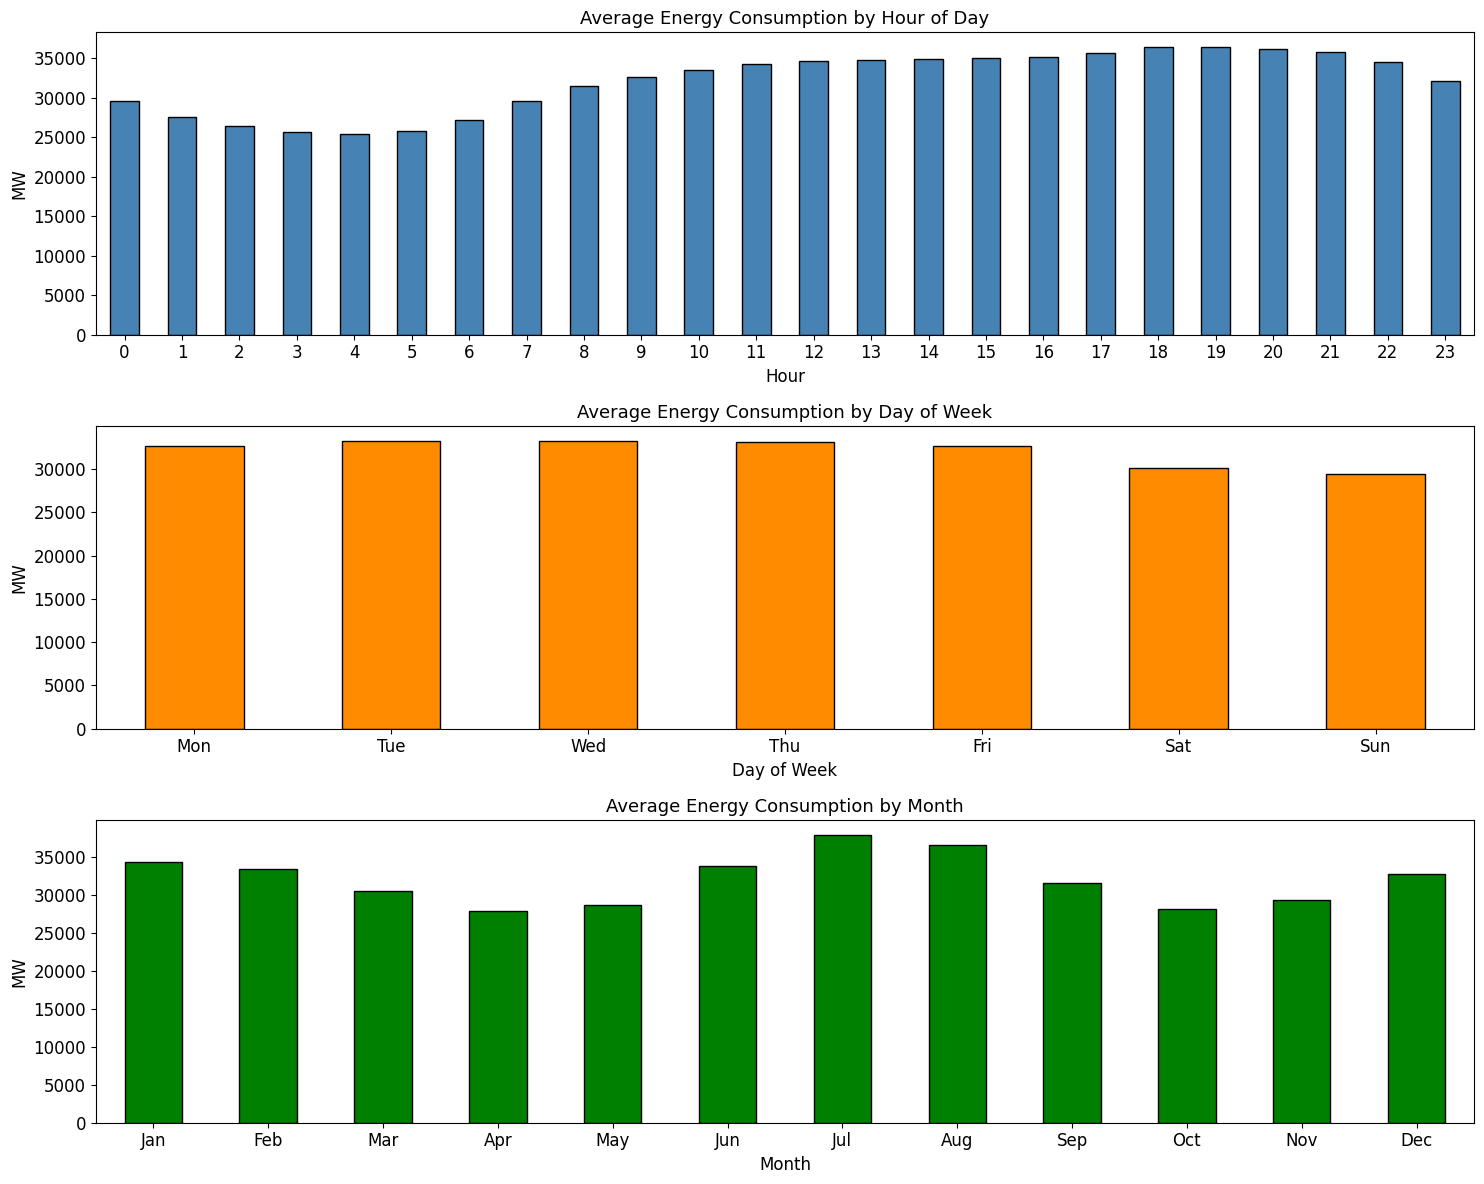

In [6]:
# Add time feature columns for grouping
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek  # 0=Monday, 6=Sunday
df['month'] = df.index.month

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1 — Average by Hour of Day
df.groupby('hour')['energy_mw'].mean().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Average Energy Consumption by Hour of Day', fontsize=13)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('MW')
axes[0].set_xticklabels(range(24), rotation=0)

# Plot 2 — Average by Day of Week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df.groupby('day_of_week')['energy_mw'].mean().plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='black'
)
axes[1].set_title('Average Energy Consumption by Day of Week', fontsize=13)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('MW')
axes[1].set_xticklabels(day_labels, rotation=0)

# Plot 3 — Average by Month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
df.groupby('month')['energy_mw'].mean().plot(
    kind='bar', ax=axes[2], color='green', edgecolor='black'
)
axes[2].set_title('Average Energy Consumption by Month', fontsize=13)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('MW')
axes[2].set_xticklabels(month_labels, rotation=0)

plt.tight_layout()
plt.savefig('../results/plots/05_seasonality_patterns.png', dpi=150)
plt.show()

Mean         : 32,080 MW
Std Dev      : 6,464 MW
Upper Bound  : 51,472 MW
Lower Bound  : 12,688 MW

Total Outliers Found : 1318
Outlier Percentage   : 0.91%

Sample outliers:
                     energy_mw  hour  day_of_week  month
Datetime                                                
2002-06-26 13:00:00    51677.0    13            2      6
2002-06-26 14:00:00    52637.0    14            2      6
2002-06-26 15:00:00    52938.0    15            2      6
2002-06-26 16:00:00    52894.0    16            2      6
2002-06-26 17:00:00    52148.0    17            2      6
2002-06-27 15:00:00    52115.0    15            3      6
2002-06-27 16:00:00    52410.0    16            3      6
2002-06-27 17:00:00    52137.0    17            3      6
2002-07-02 14:00:00    52336.0    14            1      7
2002-07-02 15:00:00    53405.0    15            1      7


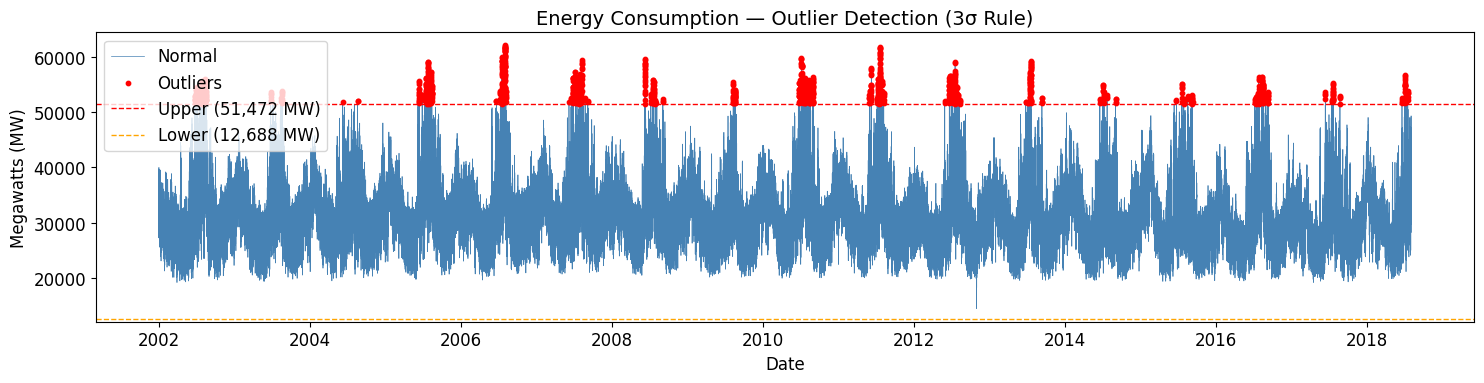

In [7]:
# Calculate mean and standard deviation
mean_mw = df['energy_mw'].mean()
std_mw = df['energy_mw'].std()

# Define outlier boundaries (3 standard deviations rule)
upper_bound = mean_mw + 3 * std_mw
lower_bound = mean_mw - 3 * std_mw

print(f"Mean         : {mean_mw:,.0f} MW")
print(f"Std Dev      : {std_mw:,.0f} MW")
print(f"Upper Bound  : {upper_bound:,.0f} MW")
print(f"Lower Bound  : {lower_bound:,.0f} MW")

# Find outliers
outliers = df[(df['energy_mw'] > upper_bound) | 
              (df['energy_mw'] < lower_bound)]

print(f"\nTotal Outliers Found : {len(outliers)}")
print(f"Outlier Percentage   : {len(outliers)/len(df)*100:.2f}%")
print(f"\nSample outliers:")
print(outliers.head(10))

# Visualize
plt.figure(figsize=(15, 4))
plt.plot(df['energy_mw'], linewidth=0.5, 
         color='steelblue', label='Normal')
plt.scatter(outliers.index, outliers['energy_mw'], 
            color='red', s=10, zorder=5, label='Outliers')
plt.axhline(y=upper_bound, color='red', 
            linestyle='--', linewidth=1, label=f'Upper ({upper_bound:,.0f} MW)')
plt.axhline(y=lower_bound, color='orange', 
            linestyle='--', linewidth=1, label=f'Lower ({lower_bound:,.0f} MW)')
plt.title('Energy Consumption — Outlier Detection (3σ Rule)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Megawatts (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/06_outlier_detection.png', dpi=150)
plt.show()

In [8]:
from statsmodels.tsa.stattools import adfuller

# Run Augmented Dickey-Fuller Test
result = adfuller(df['energy_mw'].dropna())

print('=' * 45)
print('   Augmented Dickey-Fuller (ADF) Test')
print('=' * 45)
print(f'ADF Statistic  : {result[0]:.4f}')
print(f'p-value        : {result[1]:.4f}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}    : {value:.4f}')

print('\n' + '=' * 45)
if result[1] <= 0.05:
    print('✅ RESULT: Data is STATIONARY')
    print('   (p-value ≤ 0.05, reject null hypothesis)')
else:
    print('❌ RESULT: Data is NON-STATIONARY')
    print('   (p-value > 0.05, fail to reject null hypothesis)')
print('=' * 45)

   Augmented Dickey-Fuller (ADF) Test
ADF Statistic  : -19.8813
p-value        : 0.0000
Critical Values:
   1%    : -3.4304
   5%    : -2.8616
   10%    : -2.5668

✅ RESULT: Data is STATIONARY
   (p-value ≤ 0.05, reject null hypothesis)


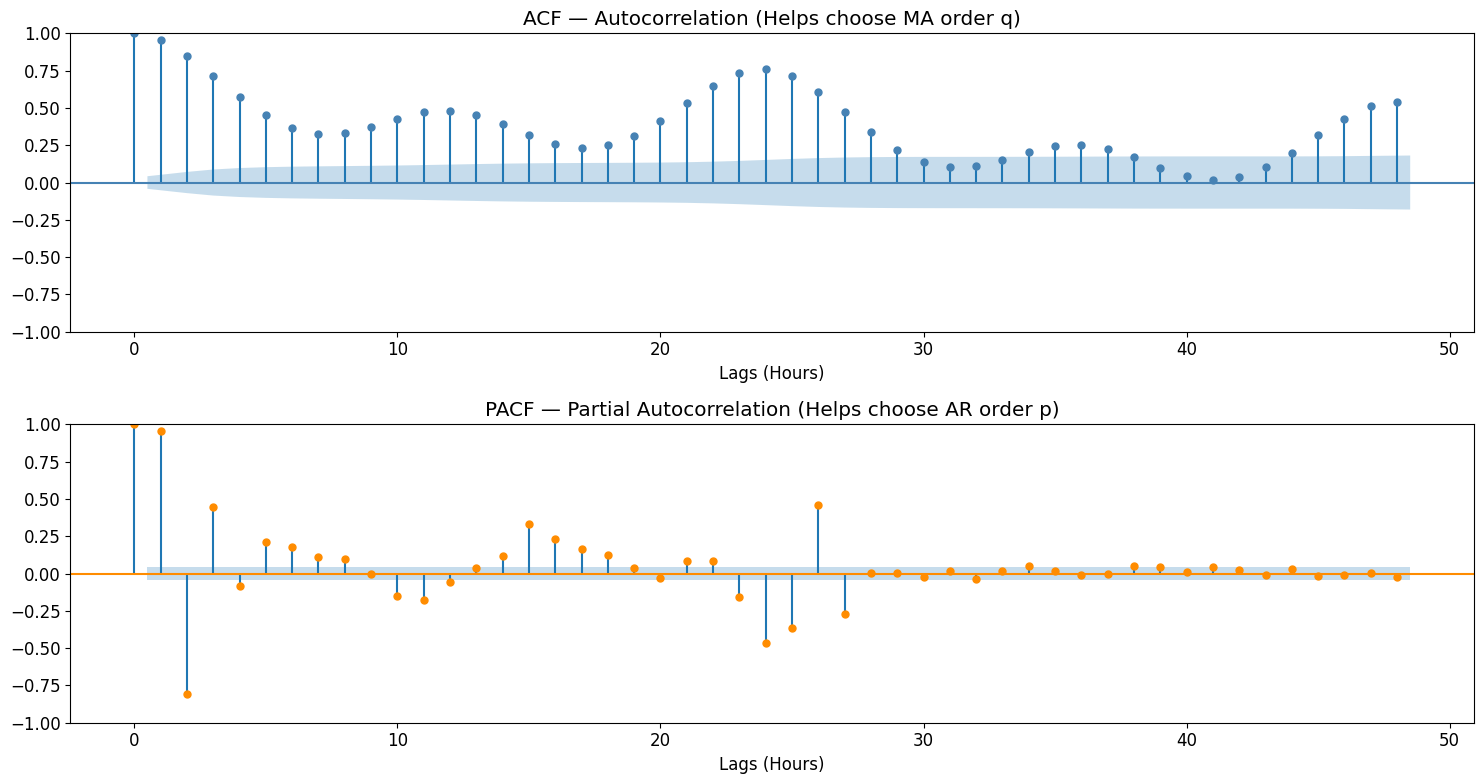

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use a sample to keep computation fast (1 month of hourly data)
sample = df['energy_mw'].loc['2017-01-01':'2017-03-31']

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# ACF Plot
plot_acf(sample, 
         lags=48, 
         ax=axes[0], 
         color='steelblue',
         title='ACF — Autocorrelation (Helps choose MA order q)')
axes[0].set_xlabel('Lags (Hours)')

# PACF Plot
plot_pacf(sample, 
          lags=48, 
          ax=axes[1], 
          color='darkorange',
          method='ywm',
          title='PACF — Partial Autocorrelation (Helps choose AR order p)')
axes[1].set_xlabel('Lags (Hours)')

plt.tight_layout()
plt.savefig('../results/plots/07_acf_pacf.png', dpi=150)
plt.show()

In [10]:
# Print full EDA summary
print('=' * 50)
print('        EDA SUMMARY — PJME Energy Data')
print('=' * 50)
print(f'\n📊 DATASET')
print(f'   Rows         : {len(df):,}')
print(f'   Date Range   : {df.index.min()} → {df.index.max()}')
print(f'   Frequency    : Hourly')

print(f'\n📈 STATISTICS')
print(f'   Mean         : {df["energy_mw"].mean():,.0f} MW')
print(f'   Std Dev      : {df["energy_mw"].std():,.0f} MW')
print(f'   Min          : {df["energy_mw"].min():,.0f} MW')
print(f'   Max          : {df["energy_mw"].max():,.0f} MW')

print(f'\n⚠️  OUTLIERS')
mean_mw = df['energy_mw'].mean()
std_mw = df['energy_mw'].std()
upper_bound = mean_mw + 3 * std_mw
lower_bound = mean_mw - 3 * std_mw
outliers = df[(df['energy_mw'] > upper_bound) |
              (df['energy_mw'] < lower_bound)]
print(f'   Count        : {len(outliers):,}')
print(f'   Percentage   : {len(outliers)/len(df)*100:.2f}%')

print(f'\n🌊 SEASONALITY PATTERNS FOUND')
print(f'   ✅ Daily seasonality   (24 hour cycle)')
print(f'   ✅ Weekly seasonality  (7 day cycle)')
print(f'   ✅ Annual seasonality  (12 month cycle)')

print(f'\n📉 STATIONARITY')
print(f'   ADF p-value  : 0.0000')
print(f'   Result       : ✅ Stationary')

print(f'\n🔁 AUTOCORRELATION')
print(f'   ACF          : Slow decay, spike at lag 24')
print(f'   PACF         : Sharp cutoff after lag 2')
print(f'   Suggested AR : p = 1 or 2')
print('=' * 50)

        EDA SUMMARY — PJME Energy Data

📊 DATASET
   Rows         : 145,366
   Date Range   : 2002-01-01 01:00:00 → 2018-08-03 00:00:00
   Frequency    : Hourly

📈 STATISTICS
   Mean         : 32,080 MW
   Std Dev      : 6,464 MW
   Min          : 14,544 MW
   Max          : 62,009 MW

⚠️  OUTLIERS
   Count        : 1,318
   Percentage   : 0.91%

🌊 SEASONALITY PATTERNS FOUND
   ✅ Daily seasonality   (24 hour cycle)
   ✅ Weekly seasonality  (7 day cycle)
   ✅ Annual seasonality  (12 month cycle)

📉 STATIONARITY
   ADF p-value  : 0.0000
   Result       : ✅ Stationary

🔁 AUTOCORRELATION
   ACF          : Slow decay, spike at lag 24
   PACF         : Sharp cutoff after lag 2
   Suggested AR : p = 1 or 2
